In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']=='cumulative')
idx = np.where(mask)[0]
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

52268
52023


In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05


In [6]:
# Require a minimum depth for the deep coadd
min_depth = 2000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

Min depth 36843 6525 0.8495434421693414
36843
36704


In [7]:
# Remove duplicates
_, idx = np.unique(zbest['TARGETID'], return_index=True)
zbest = zbest[idx]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

36704
36704


In [8]:
# Ting-Wen's quality cuts
mask = zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['Z']<1.4
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['DELTACHI2']>20
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 36339 365 0.9900555797733217
Quality cuts 35930 774 0.9789123801220575
Quality cuts 35658 1046 0.9715017436791631
35658


__Add MEDIUM and WISE masks__

In [9]:
maskbits = [1, 8, 11, 12, 13]
# min_nobs = 2

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.07431712378708845


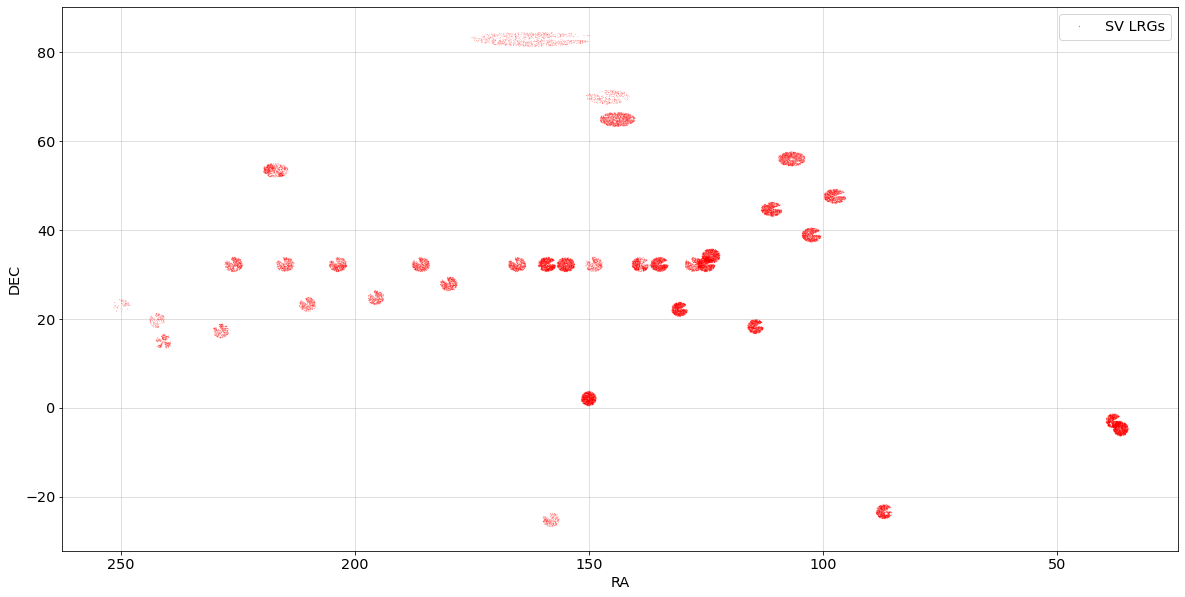

In [10]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [11]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']) - 3.214 * zbest['EBV']
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']) - 2.165 * zbest['EBV']
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']) - 1.211 * zbest['EBV']
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']) - 0.184 * zbest['EBV']
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']) - 0.113 * zbest['EBV']
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']) - 3.214 * zbest['EBV']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']) - 2.165 * zbest['EBV']
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']) - 1.211 * zbest['EBV']

In [12]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [13]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# mask_north = zbest['PHOTSYS']=='N'
# mask_south = zbest['PHOTSYS']=='S'

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

12344


In [14]:
# print(np.sum(lrg_sv3)/len(lrg_sv3))
# zbest = zbest[lrg_sv3]
# print(len(zbest))

# gmag = zbest['gmag']
# rmag = zbest['rmag']
# zmag = zbest['zmag']
# w1mag = zbest['w1mag']
# w2mag = zbest['w2mag']
# rfibermag = zbest['rfibermag']
# zfibermag = zbest['zfibermag']

--------

In [15]:
redshift = zbest['Z']

In [16]:
# Load stars from a sweep catalog
cat_psf = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/south/sweep/9.0/sweep-120p010-130p015.fits',
                  columns=['TYPE','NOBS_G', 'NOBS_R', 'NOBS_Z', 'FLUX_Z', 'FIBERFLUX_Z', 'FLUX_IVAR_Z', 'MW_TRANSMISSION_Z']))
print(len(cat_psf))
cat_psf['FLUX_Z_EC'] = cat_psf['FLUX_Z']/cat_psf['MW_TRANSMISSION_Z']
cat_psf['FIBERFLUX_Z_EC'] = cat_psf['FIBERFLUX_Z']/cat_psf['MW_TRANSMISSION_Z']
mask = cat_psf['TYPE']=='PSF'
mask &= (cat_psf['NOBS_G']>=2) & (cat_psf['NOBS_R']>=2) & (cat_psf['NOBS_Z']>=2)
mask &= (cat_psf['FLUX_Z_EC']>0) & (cat_psf['FLUX_IVAR_Z']>0)
mask &= (cat_psf['FLUX_Z_EC'] > 10**(0.4*(22.5-20.5))) # zmag<20.5
idx = np.where(mask)[0]
print(len(idx))

cat_psf = Table(fitsio.read('/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/south/sweep/9.0/sweep-120p010-130p015.fits',
                  rows=idx))
cat_psf['TYPE'] = cat_psf['TYPE']

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_G']) - 3.214 * cat_psf['EBV']
    rmag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_R']) - 2.165 * cat_psf['EBV']
    zmag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_Z']) - 1.211 * cat_psf['EBV']
    w1mag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_W1']) - 0.184 * cat_psf['EBV']
    w2mag_psf = 22.5 - 2.5*np.log10(cat_psf['FLUX_W2']) - 0.113 * cat_psf['EBV']
    rfibermag_psf = 22.5 - 2.5*np.log10(cat_psf['FIBERFLUX_R']) - 2.165 * cat_psf['EBV']
    zfibermag_psf = 22.5 - 2.5*np.log10(cat_psf['FIBERFLUX_Z']) - 1.211 * cat_psf['EBV']

    gmag_psf[~np.isfinite(gmag_psf)] = 100.
    rmag_psf[~np.isfinite(rmag_psf)] = 100.
    zmag_psf[~np.isfinite(zmag_psf)] = 100.
    w1mag_psf[~np.isfinite(w1mag_psf)] = 100.
    w2mag_psf[~np.isfinite(w2mag_psf)] = 100.
    rfibermag_psf[~np.isfinite(rfibermag_psf)] = 100.
    zfibermag_psf[~np.isfinite(zfibermag_psf)] = 100.

4390932
463362


In [17]:
# 800/sqdeg
sv3_full_params = {
    'zfiber_max':21.7,
    'ns_a':0.8, 'ns_b':-0.6,
    'lowz_a':-1.55, 'lowz_b':3.13,
    'lowz_gr':1.3, 'lowz_rw1':1.8,
    'rw1_highz':3.29,
    'ir_slope1':1.8, 'ir_slope2':1.,
    'ir_inter1':-17.26,  'ir_inter2':-16.36, 
}

# 800/sqdeg
sv3_subset_params = {
    'ir_slope1':1.8, 'ir_slope2':1.,
    'ir_inter1':-17.07,  'ir_inter2':-16.17, 
    'rw1_highz':3.39,
}

# point where the two nominal sliding cuts meet
a1, b1, a2, b2 = sv3_full_params['ir_slope1'], sv3_full_params['ir_slope1']*sv3_full_params['ir_inter1'], sv3_full_params['ir_slope2'], sv3_full_params['ir_slope2']*sv3_full_params['ir_inter2']
yc = (a2*b1-a1*b2)/(a2-a1)
xc = (yc-b1)/a1
print(yc, xc)
a1, b1, a2, b2 = sv3_subset_params['ir_slope1'], sv3_subset_params['ir_slope1']*sv3_subset_params['ir_inter1'], sv3_subset_params['ir_slope2'], sv3_subset_params['ir_slope2']*sv3_subset_params['ir_inter2']
yc1 = (a2*b1-a1*b2)/(a2-a1)
xc1 = (yc1-b1)/a1
print(yc1, xc1)

2.0250000000000057 18.385000000000005
2.024999999999997 18.194999999999997


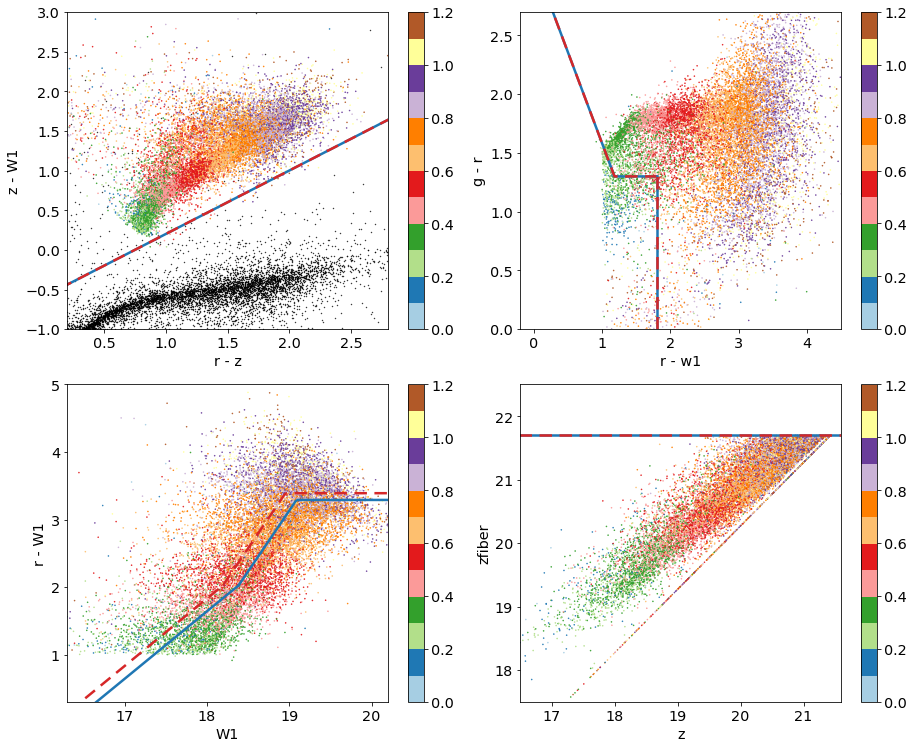

In [18]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)

np.random.seed(342)
idx_psf = np.random.choice(len(cat_psf), size=10000, replace=False)
mask = (zfibermag<21.7) & (~mask_star)
idx_all = np.random.choice(np.where(mask)[0], size=15000, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 10.5))

################# non-stellar cut #################
axes[0, 0].scatter((rmag_psf-zmag_psf)[idx_psf], (zmag_psf-w1mag_psf)[idx_psf], 
            c='k', s=0.15, vmin=0., vmax=1.2)
im = axes[0, 0].scatter((rmag-zmag)[idx_all], (zmag-w1mag)[idx_all], 
            c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[0, 0].set_xlabel('r - z')
axes[0, 0].set_ylabel('z - W1')
axes[0, 0].axis([0.2, 2.8, -1, 3])
fig.colorbar(im, ax=axes[0, 0])

# Lines -- 800/sqdeg and 600/sqdeg
x = np.linspace(0, 3)
y = sv3_full_params['ns_a'] * x + sv3_full_params['ns_b']
axes[0, 0].plot(x, y, 'C0', lw=2.5)
axes[0, 0].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))

################# g-r vs r-W1 #################
im = axes[0, 1].scatter((rmag-w1mag)[idx_all], (gmag-rmag)[idx_all], 
         c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[0, 1].set_xlabel('r - w1')
axes[0, 1].set_ylabel('g - r')
axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
fig.colorbar(im, ax=axes[0, 1])

# Lines -- 800/sqdeg and 600/sqdeg
x1 = np.linspace(-2, sv3_full_params['lowz_rw1'], 1000)
y1 = sv3_full_params['lowz_a'] * x1 + sv3_full_params['lowz_b']
y1[y1<=1.3] = sv3_full_params['lowz_gr']
axes[0, 1].plot(x1, y1, 'C0', lw=2.5)
axes[0, 1].plot(x1, y1, 'C3', lw=2.5, ls='--', dashes=(5, 3))
y2 = np.linspace(-5, 1.3)
x2 = 1.8 * np.ones_like(y2)
axes[0, 1].plot(x2, y2, 'C0', lw=2.5)
axes[0, 1].plot(x2, y2, 'C3', lw=2.5, ls='--', dashes=(5, 3))

################# IR sliding cut #################
im = axes[1, 0].scatter((w1mag)[idx_all], (rmag-w1mag)[idx_all], 
         c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[1, 0].set_xlabel('W1')
axes[1, 0].set_ylabel('r - W1')
axes[1, 0].axis([16.3, 20.2, 0.3, 5.])
fig.colorbar(im, ax=axes[1, 0])

# Lines -- 800/sqdeg
x = np.linspace(xc, 23, 200)
y = np.zeros(len(x))
y = (x + sv3_full_params['ir_inter1']) * sv3_full_params['ir_slope1']
mask = (y>sv3_full_params['rw1_highz'])
y[mask] = sv3_full_params['rw1_highz']
axes[1, 0].plot(x, y, 'C0', lw=2.5)
x = np.linspace(15, xc, 200)
y = np.zeros(len(x))
y = (x + sv3_full_params['ir_inter2']) * sv3_full_params['ir_slope2']
axes[1, 0].plot(x, y, 'C0', lw=2.5)

# Lines -- 600/sqdeg
x = np.linspace(xc1, 23, 200)
y = np.zeros(len(x))
y = (x + sv3_subset_params['ir_inter1']) * sv3_subset_params['ir_slope1']
mask = (y>sv3_subset_params['rw1_highz'])
y[mask] = sv3_subset_params['rw1_highz']
axes[1, 0].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))
x = np.linspace(15, xc1, 200)
y = np.zeros(len(x))
y = (x + sv3_subset_params['ir_inter2']) * sv3_subset_params['ir_slope2']
axes[1, 0].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))

################# zfiber vs z #################
im = axes[1, 1].scatter((zmag)[idx_all], (zfibermag)[idx_all], 
         c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[1, 1].set_xlabel('z')
axes[1, 1].set_ylabel('zfiber')
axes[1, 1].axis([16.5, 21.6, 17.5, 22.5])
fig.colorbar(im, ax=axes[1, 1])

# Lines -- 800/sqdeg and 600/sqdeg
x = np.linspace(0, 100)
y = sv3_full_params['zfiber_max'] * np.ones_like(x)
axes[1, 1].plot(x, y, 'C0', lw=2.5)
axes[1, 1].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))

plt.tight_layout()
plt.savefig('plots/lrg_selection_all.png', dpi=110)
plt.show()

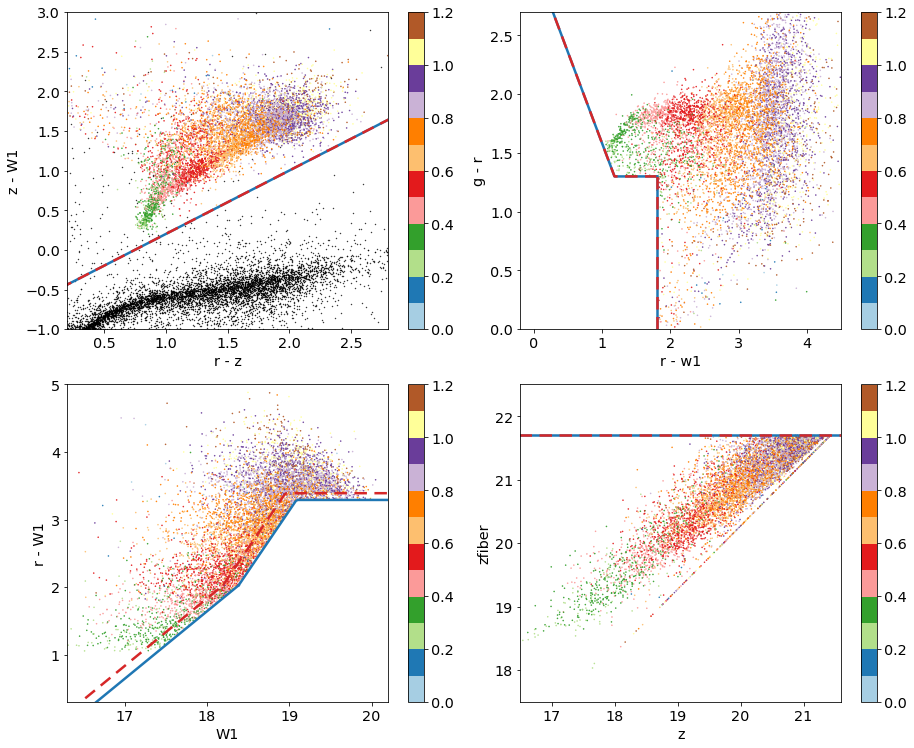

In [19]:
mask_star = (zbest['SPECTYPE']=='STAR') | (zbest['Z']<0.0003)

np.random.seed(342)
idx_psf = np.random.choice(len(cat_psf), size=10000, replace=False)
mask = (zfibermag<21.7) & (~mask_star)
idx_all = np.random.choice(np.where(mask)[0], size=15000, replace=False)
idx_lrg = np.where(lrg_sv3)[0]
idx_all = np.intersect1d(idx_all, idx_lrg)

fig, axes = plt.subplots(2, 2, figsize=(13, 10.5))

################# non-stellar cut #################
axes[0, 0].scatter((rmag_psf-zmag_psf)[idx_psf], (zmag_psf-w1mag_psf)[idx_psf], 
            c='k', s=0.15, vmin=0., vmax=1.2)
im = axes[0, 0].scatter((rmag-zmag)[idx_all], (zmag-w1mag)[idx_all], 
            c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[0, 0].set_xlabel('r - z')
axes[0, 0].set_ylabel('z - W1')
axes[0, 0].axis([0.2, 2.8, -1, 3])
fig.colorbar(im, ax=axes[0, 0])

# Lines -- 800/sqdeg and 600/sqdeg
x = np.linspace(0, 3)
y = sv3_full_params['ns_a'] * x + sv3_full_params['ns_b']
axes[0, 0].plot(x, y, 'C0', lw=2.5)
axes[0, 0].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))

################# g-r vs r-W1 #################
im = axes[0, 1].scatter((rmag-w1mag)[idx_all], (gmag-rmag)[idx_all], 
         c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[0, 1].set_xlabel('r - w1')
axes[0, 1].set_ylabel('g - r')
axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
fig.colorbar(im, ax=axes[0, 1])

# Lines -- 800/sqdeg and 600/sqdeg
x1 = np.linspace(-2, sv3_full_params['lowz_rw1'], 1000)
y1 = sv3_full_params['lowz_a'] * x1 + sv3_full_params['lowz_b']
y1[y1<=1.3] = sv3_full_params['lowz_gr']
axes[0, 1].plot(x1, y1, 'C0', lw=2.5)
axes[0, 1].plot(x1, y1, 'C3', lw=2.5, ls='--', dashes=(5, 3))
y2 = np.linspace(-5, 1.3)
x2 = 1.8 * np.ones_like(y2)
axes[0, 1].plot(x2, y2, 'C0', lw=2.5)
axes[0, 1].plot(x2, y2, 'C3', lw=2.5, ls='--', dashes=(5, 3))

################# IR sliding cut #################
im = axes[1, 0].scatter((w1mag)[idx_all], (rmag-w1mag)[idx_all], 
         c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[1, 0].set_xlabel('W1')
axes[1, 0].set_ylabel('r - W1')
axes[1, 0].axis([16.3, 20.2, 0.3, 5.])
fig.colorbar(im, ax=axes[1, 0])

# Lines -- 800/sqdeg
x = np.linspace(xc, 23, 200)
y = np.zeros(len(x))
y = (x + sv3_full_params['ir_inter1']) * sv3_full_params['ir_slope1']
mask = (y>sv3_full_params['rw1_highz'])
y[mask] = sv3_full_params['rw1_highz']
axes[1, 0].plot(x, y, 'C0', lw=2.5)
x = np.linspace(15, xc, 200)
y = np.zeros(len(x))
y = (x + sv3_full_params['ir_inter2']) * sv3_full_params['ir_slope2']
axes[1, 0].plot(x, y, 'C0', lw=2.5)

# Lines -- 600/sqdeg
x = np.linspace(xc1, 23, 200)
y = np.zeros(len(x))
y = (x + sv3_subset_params['ir_inter1']) * sv3_subset_params['ir_slope1']
mask = (y>sv3_subset_params['rw1_highz'])
y[mask] = sv3_subset_params['rw1_highz']
axes[1, 0].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))
x = np.linspace(15, xc1, 200)
y = np.zeros(len(x))
y = (x + sv3_subset_params['ir_inter2']) * sv3_subset_params['ir_slope2']
axes[1, 0].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))

################# zfiber vs z #################
im = axes[1, 1].scatter((zmag)[idx_all], (zfibermag)[idx_all], 
         c=redshift[idx_all], s=0.3, cmap='Paired', vmin=0., vmax=1.2)
axes[1, 1].set_xlabel('z')
axes[1, 1].set_ylabel('zfiber')
axes[1, 1].axis([16.5, 21.6, 17.5, 22.5])
fig.colorbar(im, ax=axes[1, 1])

# Lines -- 800/sqdeg and 600/sqdeg
x = np.linspace(0, 100)
y = sv3_full_params['zfiber_max'] * np.ones_like(x)
axes[1, 1].plot(x, y, 'C0', lw=2.5)
axes[1, 1].plot(x, y, 'C3', lw=2.5, ls='--', dashes=(5, 3))

plt.tight_layout()
plt.savefig('plots/lrg_selection_sv3.png', dpi=110)
plt.show()